## 1. Imports

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
from sklearn.preprocessing import MinMaxScaler


warnings.filterwarnings('ignore')

## 2. Load Data

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
file_path = '/content/drive/MyDrive/Retail-Demand-Forecasting-Sales-Analysis/data/cleaned/cleaned_retail_data.csv'
df = pd.read_csv(file_path)

# Ensure Date is parsed correctly
df['Date'] = pd.to_datetime(df['Date'])

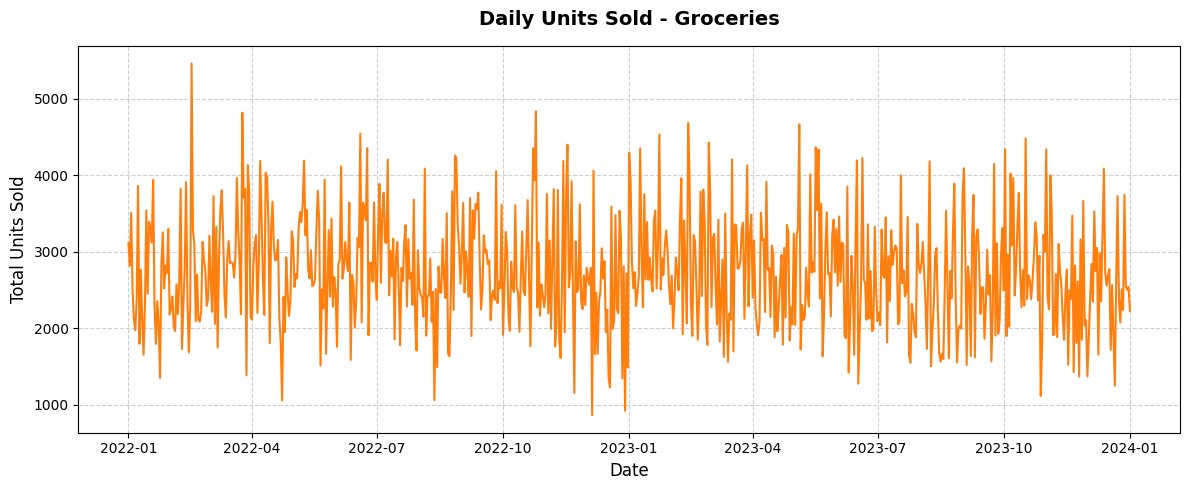

In [15]:
## 3. Forecasting Scope

# Focusing on Groceries since it showed the highest stockout rate during EDA.
# Grouping by Date and using reset_index() to turn the grouped dates back into a normal column.
target_data = df[df['Category'] == 'Groceries'].groupby('Date')['Units Sold'].sum().reset_index()

# Time series models require strictly forward-flowing time
target_data = target_data.sort_values('Date')

# Plotting to visually check for stationarity and trends before modeling
plt.figure(figsize=(12, 5))
ax = sns.lineplot(
    data=target_data,
    x='Date',
    y='Units Sold',
    color='#ff7f0e',
    linewidth=1.5
)

plt.title('Daily Units Sold - Groceries', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Total Units Sold', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 4. Train/Test Split


In [11]:
# Hold out the last 30 days as the test set to evaluate model performance
train_size = len(target_data) - 30
train = target_data.iloc[:train_size]
test = target_data.iloc[train_size:]

print(f"Training on {len(train)} days, testing on {len(test)} days.")

Training on 701 days, testing on 30 days.


## 5. Fit ARIMA Baseline

In [12]:
# Initialize ARIMA with order (5,1,0): 5 days lookback (AR), 1 differencing step (I), 0 moving average (MA)
arima_model = ARIMA(train['Units Sold'].values, order=(5, 1, 0))
arima_fitted = arima_model.fit()

# Forecast the exact number of days in the test set
predictions = arima_fitted.forecast(steps=len(test))

# Calculate Mean Absolute Error (MAE) for baseline comparison
mae = mean_absolute_error(test['Units Sold'].values, predictions)
print(f"ARIMA Baseline MAE: {mae:.2f}")

ARIMA Baseline MAE: 732.74


## 6. Plot Predicted vs Actual

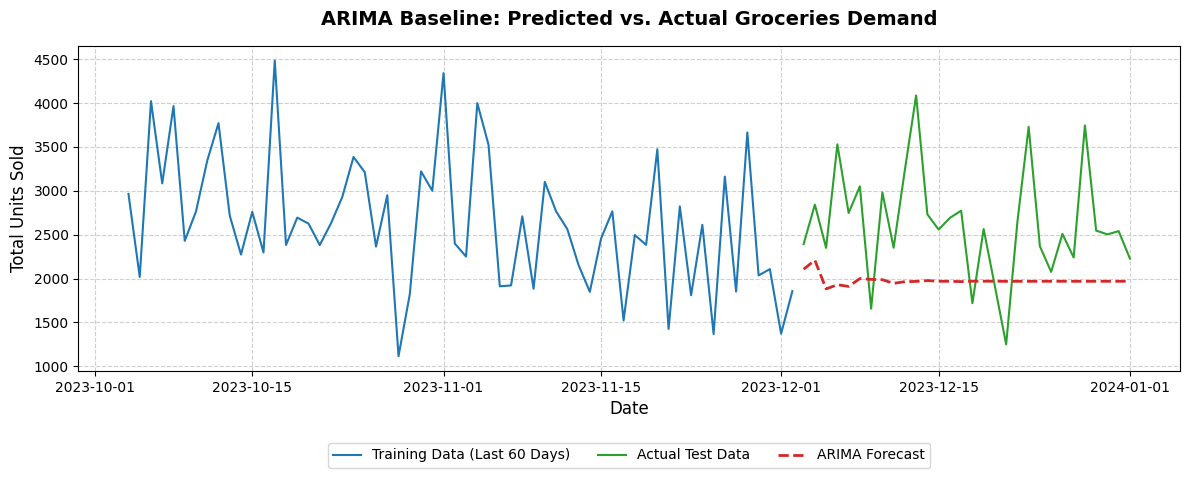

In [14]:
# Plot the last 60 days of training data for context alongside the test and prediction lines
plt.figure(figsize=(12, 5))
plt.plot(train['Date'].tail(60), train['Units Sold'].tail(60), label='Training Data (Last 60 Days)', color='#1f77b4')
plt.plot(test['Date'], test['Units Sold'], label='Actual Test Data', color='#2ca02c')
plt.plot(test['Date'], predictions, label='ARIMA Forecast', color='#d62728', linestyle='--', linewidth=2)

plt.title('ARIMA Baseline: Predicted vs. Actual Groceries Demand', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Units Sold', fontsize=12)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 7. LSTM Preprocessing

In [20]:
# I'm scaling the data between 0 and 1. Neural networks struggle to learn when features have large, raw integer values.
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train[['Units Sold']])
scaled_test = scaler.transform(test[['Units Sold']])

# I need to create a sliding window of data for the LSTM to learn from.
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), 0])
        y.append(data[i + window_size, 0])
    return np.array(X), np.array(y)

# Window size of 14 means the model looks at the last two weeks to forecast the next day
window_size = 14
X_train, y_train = create_sequences(scaled_train, window_size)
X_test, y_test = create_sequences(scaled_test, window_size)

# Keras LSTMs
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"LSTM Training shape: {X_train.shape}")
print(f"LSTM Testing shape: {X_test.shape}")

LSTM Training shape: (687, 14, 1)
LSTM Testing shape: (16, 14, 1)
